# **ROTEIRO 2 - TEMA: Aplicação Prática de Python na Ciência dos Dados - Parte 2**

**Aluno:** Isaac Eliseu Alcântara Silva

**Disciplina:** Ciência dos Dados Para Tomada de Decisões

**Professor:** Sergio Ricardo

Neste roteiro de atividade 2, serão examinadas características financeiras da planilha "default_of_credit_card_clients__courseware_version_1_21_19.xls" (data set que será utilizado na atividade), para praticar a manipulação e visualização dos dados.

## *Importando as bibliotecas necessárias*

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

## *Importando a planilha*

In [4]:
df = pd.read_excel('default_of_credit_card_clients__courseware_version_1_21_19.xls')

## **Questão 1**

In [5]:
bill_feats = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

In [6]:
pay_feats = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

**---> *1.Análise (resposta):*** Foram criadas as listas bill_feats e pay_feats para separar as variáveis de fatura e pagamento. Essa organização facilita a manipulação e permite análises mais direcionadas para cada tipo de informação financeira.

## **Questão 2**

In [7]:
df[bill_feats].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


**---> *2.Análise (resposta):*** As estatísticas das faturas (BILL_AMT) mostram alta variação nos valores, com presença de mínimos negativos, indicando possíveis créditos. As médias se mantêm próximas entre os períodos e o alto desvio padrão evidencia grande dispersão. Esses resultados fazem sentido, pois refletem diferentes perfis de consumo entre os clientes.

## **Questão 3**

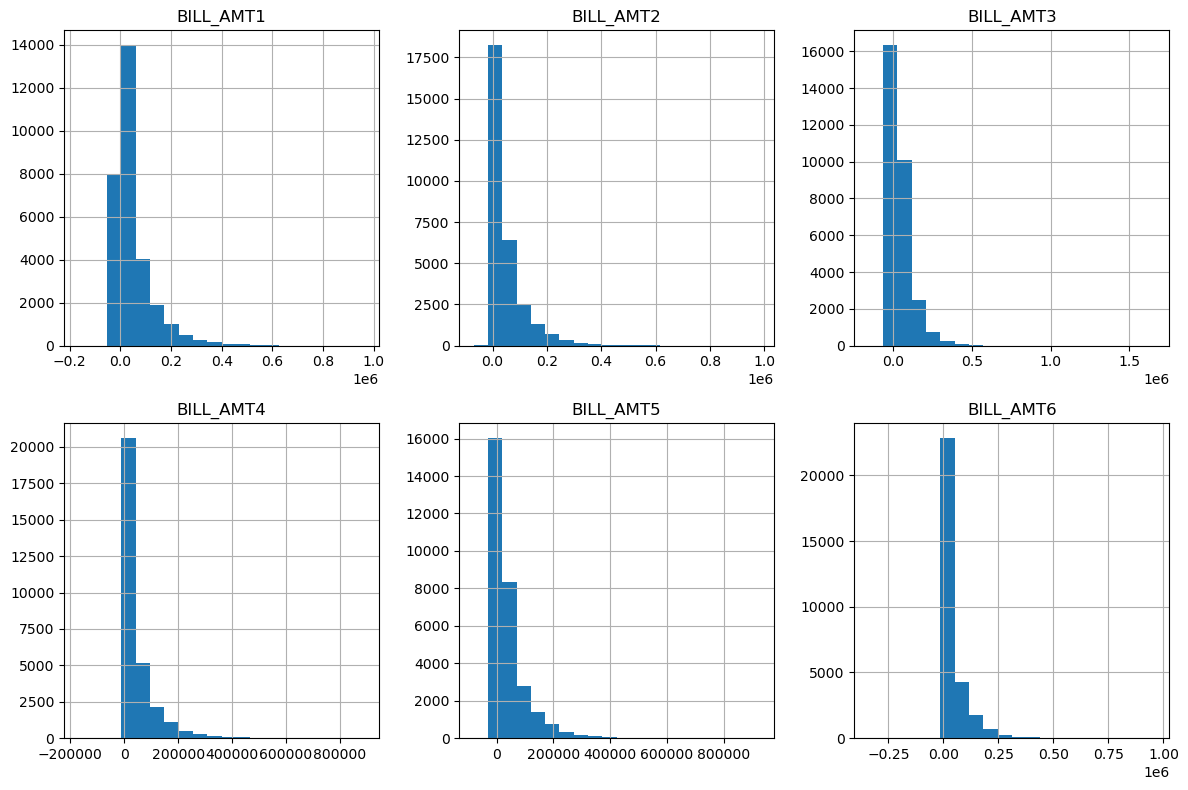

In [8]:
df[bill_feats].hist(bins=20, layout=(2,3), figsize=(12,8))
plt.tight_layout()
plt.show()

**-------> *3.Análise (resposta):*** Os histogramas mostram maior concentração de valores nas faixas mais baixas, com redução gradual conforme os valores aumentam. Esse padrão indica que poucos clientes concentram valores muito altos, o que é comum em dados financeiros e confirma o comportamento observado nas estatísticas.

## **Questão 4**

In [9]:
df[pay_feats].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


**-------> *4.Análise (resposta):*** Os pagamentos (PAY_AMT) apresentam médias menores que as faturas e valores mínimos iguais a zero em todas as variáveis. O alto desvio padrão indica grande variação no comportamento de pagamento. Esses resultados fazem sentido, pois nem todos os clientes pagam integralmente suas faturas.

## **Questão 5**

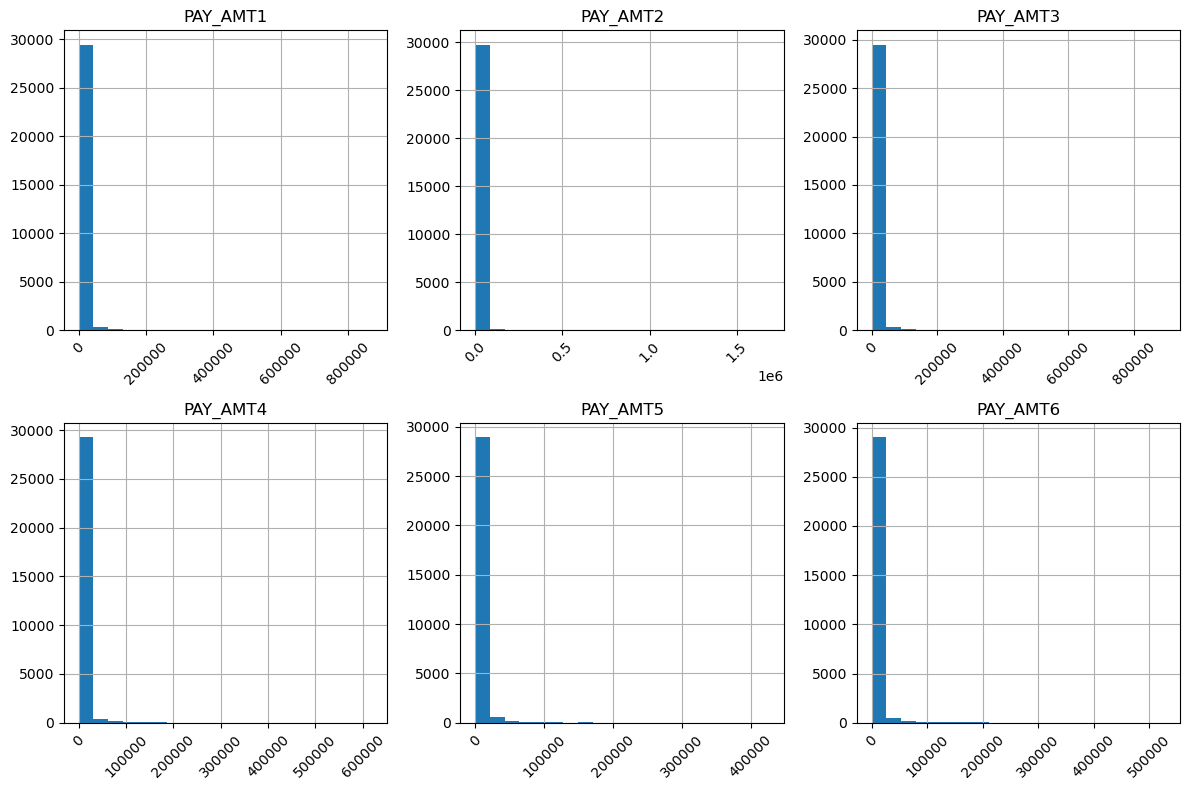

In [10]:
df[pay_feats].hist(bins=20, layout=(2,3), figsize=(12,8), xrot=45)
plt.tight_layout()
plt.show()

**-------> *5.Análise (resposta):*** A rotação dos rótulos melhorou a leitura dos gráficos. Os histogramas mostram forte concentração de valores próximos de zero, com poucos casos de pagamentos mais altos, o que está coerente com os dados estatísticos observados anteriormente.

## **Questão 6**

In [11]:
pagamento_zero_mask = df[pay_feats] == 0

In [12]:
pagamento_zero_mask.sum()

PAY_AMT1    5504
PAY_AMT2    5663
PAY_AMT3    6223
PAY_AMT4    6660
PAY_AMT5    6955
PAY_AMT6    7416
dtype: int64

**-------> *6.Análise (resposta):*** A máscara booleana confirma a presença de muitos pagamentos iguais a zero em todos os períodos. Esse resultado faz sentido, pois corresponde à concentração observada nos gráficos, indicando uma parcela relevante de clientes sem pagamento registrado.

## **Questão 7**

In [13]:
df_log = df[pay_feats][~pagamento_zero_mask].apply(np.log10)

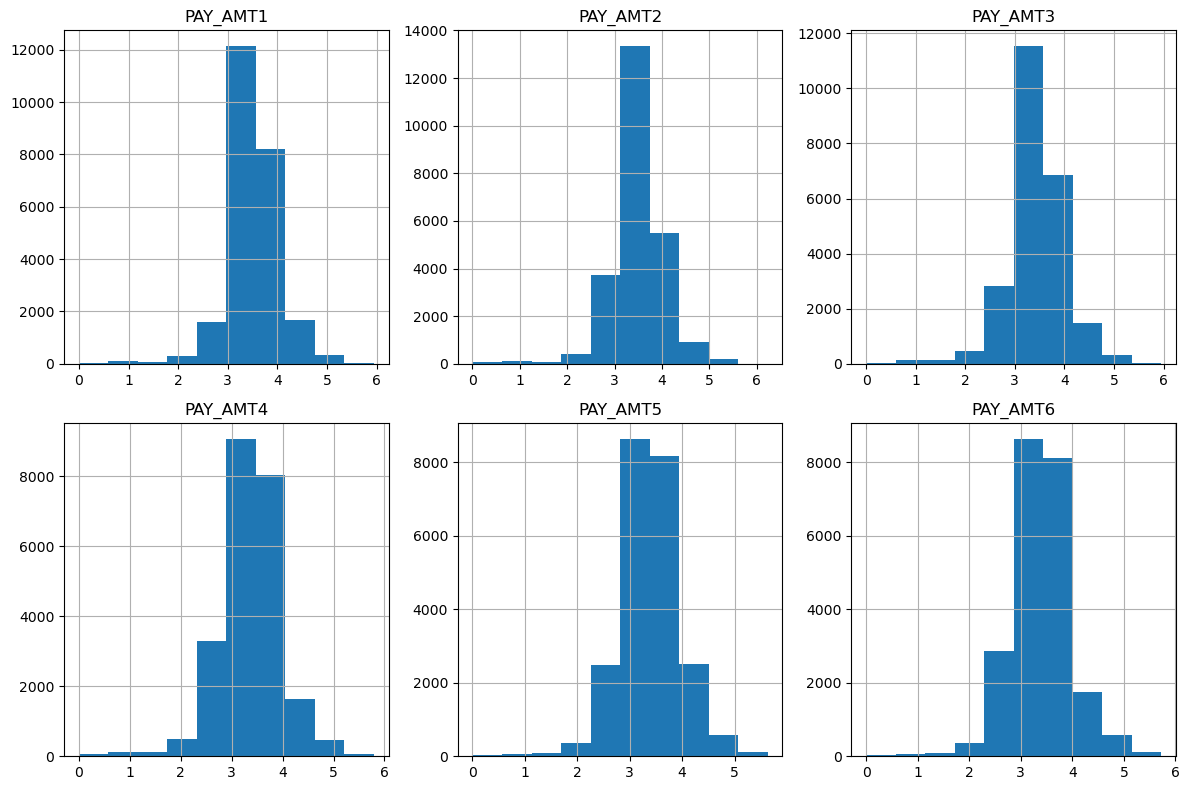

In [14]:
df_log.hist(layout=(2,3), figsize=(12,8))
plt.tight_layout()
plt.show()

**-------> *7.Análise (resposta):*** Após remover os valores zero e aplicar o logaritmo, os dados passam a apresentar uma distribuição mais equilibrada, reduzindo a concentração em valores muito baixos. Esse resultado facilita a visualização dos padrões e torna a análise mais clara.